# Control Sintético — Suspensión de la Troncal Ciudad Bolívar (octubre 2025)

**Pregunta:** ¿Cuántas validaciones perdió la Troncal Zona T (Ciudad Bolívar) durante su suspensión de servicio del 4 al 19 de octubre de 2025?

**Identificación:** A partir del 4 de octubre la afluencia en la línea 40 cayó de ~58 000 a <600 validaciones/día en los días pico de interrupción (4-17 oct), con una reducción promedio del período del ~92%. El resto de las 11 troncales muestra patrones estables. El choque es atribuible a un evento exógeno en el corredor (consistente con un cierre vial por emergencia geotécnica en las laderas de Ciudad Bolívar). La exogeneidad se apoya en que la interrupción no correlaciona con la demanda sistémica.

**Método:** Control Sintético (Abadie, Diamond & Hainmueller, 2010):
$$
\hat{Y}^{\text{sint}}_{40,t} = \sum_{j \neq 40} w_j^* \cdot Y_{j,t}
\qquad \text{donde } w^* = \arg\min_w \sum_{t < T_0} \bigl(Y_{40,t} - \textstyle\sum_j w_j Y_{j,t}\bigr)^2,\quad w_j \geq 0,\; \sum_j w_j = 1
$$

El efecto causal estimado en cada día post-tratamiento es:
$$
\hat{\tau}_t = Y_{40,t} - \hat{Y}^{\text{sint}}_{40,t}
$$

**Inferencia:** Placebos en espacio — el mismo estimador se aplica a cada troncal del pool de donantes. La razón RMSPE post/pre mide la rareza del resultado observado.

In [1]:
import pandas as pd
import numpy as np
import json
import warnings
import glob
from pathlib import Path
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

PROJ = Path('..').resolve()
(PROJ / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

LINEAS = json.load(open(PROJ / 'data/processed/dim_linea.json'))
LINEAS_NOMBRE = {int(k): v for k, v in LINEAS.items()}

TREATED   = 40
T0_DATE   = pd.Timestamp('2025-10-04')
TEND_DATE = pd.Timestamp('2025-10-19')
VIS_END   = pd.Timestamp('2025-10-31')

TM_ROJO = '#C1001F'
TM_AZUL = '#1A5276'


## 1. El evento: suspensión de la Troncal Ciudad Bolívar

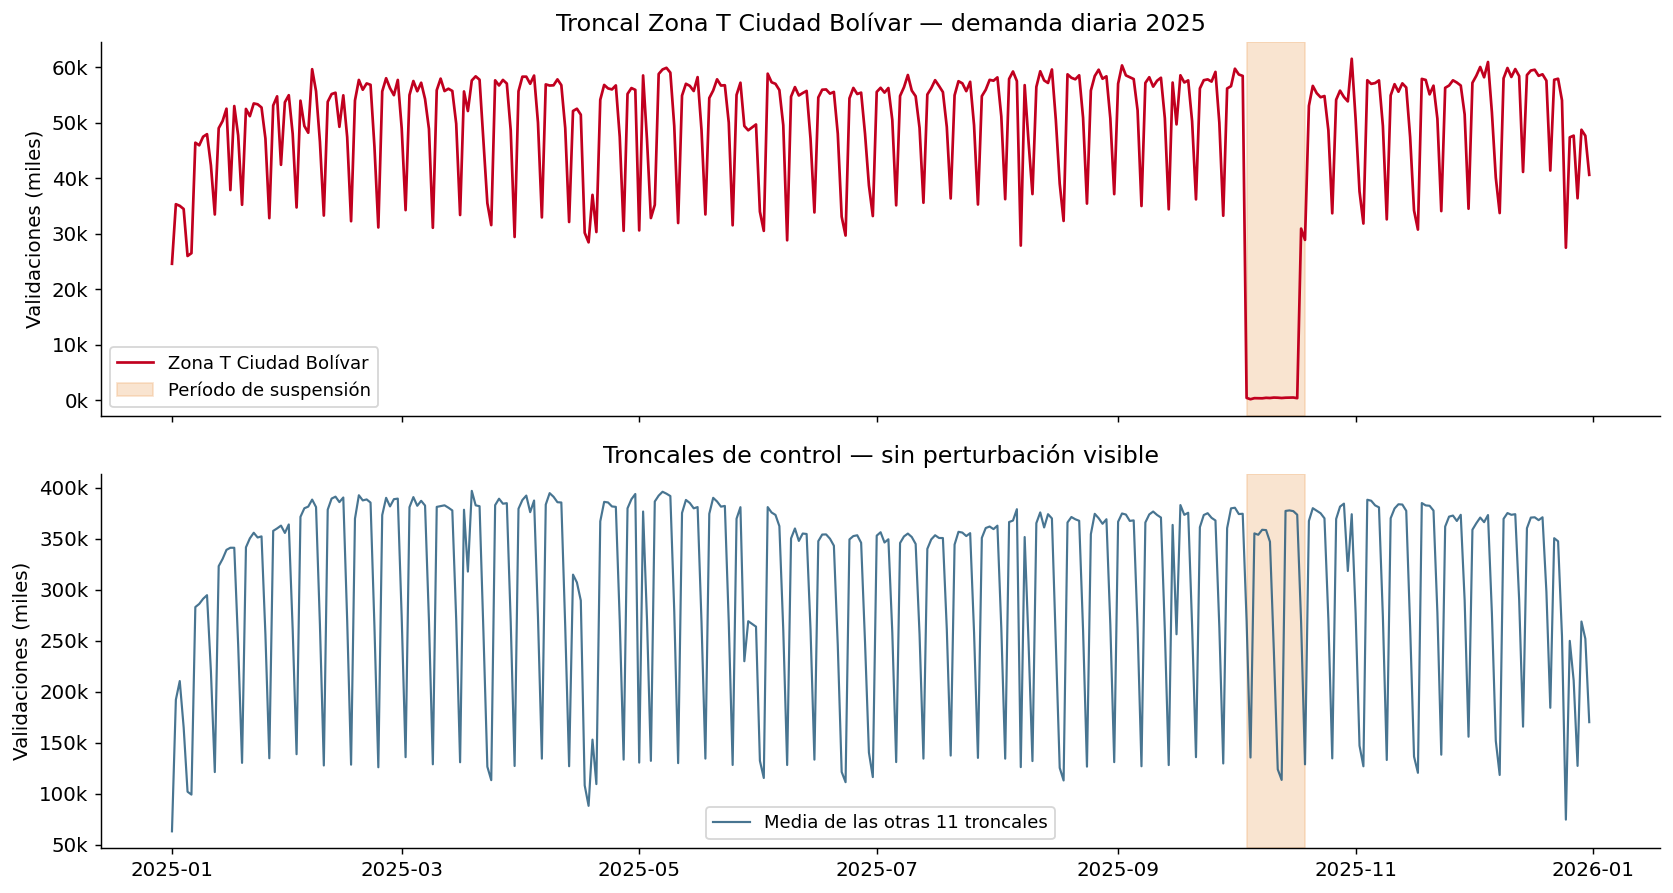

Media pre-suspensión (2025):              50,272 validaciones/día
Media durante suspensión (oct 4-19):       4,114 validaciones/día
Reducción observada:                        91.8%
Días de suspensión:                           16


In [2]:
frames = []
for f in sorted(glob.glob(str(PROJ / 'data/processed/parquet/*.parquet'))):
    d = pd.read_parquet(f)
    agg = d.groupby(['fecha', 'codigo_linea'])['total'].sum().reset_index()
    frames.append(agg)

panel = (
    pd.concat(frames, ignore_index=True)
      .assign(fecha=lambda x: pd.to_datetime(x.fecha))
      .sort_values(['codigo_linea', 'fecha'])
      .reset_index(drop=True)
)

l40 = panel[panel.codigo_linea == TREATED].copy()
sys_mean = (
    panel[panel.codigo_linea != TREATED]
    .groupby('fecha')['total'].mean()
    .reset_index().rename(columns={'total': 'sys_mean'})
)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(l40.fecha, l40.total / 1e3, color=TM_ROJO, lw=1.5, label='Zona T Ciudad Bolívar')
ax.axvspan(T0_DATE, TEND_DATE, color='#f0b27a', alpha=0.35, label='Período de suspensión')
ax.set_ylabel('Validaciones (miles)')
ax.set_title('Troncal Zona T Ciudad Bolívar — demanda diaria 2025')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

ax2 = axes[1]
ax2.plot(sys_mean.fecha, sys_mean.sys_mean / 1e3, color=TM_AZUL, lw=1.2, alpha=0.8,
         label='Media de las otras 11 troncales')
ax2.axvspan(T0_DATE, TEND_DATE, color='#f0b27a', alpha=0.35)
ax2.set_ylabel('Validaciones (miles)')
ax2.set_title('Troncales de control — sin perturbación visible')
ax2.legend(fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

fig.tight_layout()
fig.savefig(PROJ / 'reports/figures/ciudad_bolivar_evento.png', bbox_inches='tight')
plt.show()

pre_mean  = l40[l40.fecha < T0_DATE]['total'].mean()
post_mean = l40[(l40.fecha >= T0_DATE) & (l40.fecha <= TEND_DATE)]['total'].mean()
print(f"Media pre-suspensión (2025):          {pre_mean:>10,.0f} validaciones/día")
print(f"Media durante suspensión (oct 4-19):  {post_mean:>10,.0f} validaciones/día")
print(f"Reducción observada:                  {(1 - post_mean/pre_mean)*100:>10.1f}%")
print(f"Días de suspensión:                   {(TEND_DATE - T0_DATE).days + 1:>10}")


## 2. Construcción del panel y ajuste estacional

Eliminamos la estacionalidad semanal dividiendo cada observación por la media del día de semana correspondiente en el pre-período para esa línea. Esto retira el ciclo lunes–viernes/fin de semana sin usar información del post-período.

In [3]:
panel['dow'] = panel.fecha.dt.dayofweek

pre_mask = panel.fecha < T0_DATE
dow_means = (
    panel[pre_mask]
    .groupby(['codigo_linea', 'dow'])['total'].mean()
    .reset_index().rename(columns={'total': 'dow_mean'})
)
panel = panel.merge(dow_means, on=['codigo_linea', 'dow'], how='left')
panel['total_norm'] = panel['total'] / panel['dow_mean']

wide = (
    panel.pivot(index='fecha', columns='codigo_linea', values='total_norm')
    .sort_index()
)
wide.columns = [int(c) for c in wide.columns]

pre  = wide[wide.index < T0_DATE]
post = wide[(wide.index >= T0_DATE) & (wide.index <= VIS_END)]

donor_cols = [c for c in wide.columns if c != TREATED]

print(f"Pre-período:  {pre.index[0].date()} → {pre.index[-1].date()} ({len(pre)} días)")
print(f"Post-período: {post.index[0].date()} → {post.index[-1].date()} ({len(post)} días)")
print(f"Donantes:     {len(donor_cols)} troncales")


Pre-período:  2025-01-01 → 2025-10-03 (275 días)
Post-período: 2025-10-04 → 2025-10-31 (28 días)
Donantes:     11 troncales


\
## 3. Optimización de pesos sintéticos

Resolvemos el problema cuadrático constreñido:
$$
w^* = \arg\min_{w \in \Delta^{J-1}} \; \|Y_{40}^{\text{pre}} - W \cdot Y_{\text{donantes}}^{\text{pre}}\|^2
$$
donde $\Delta^{J-1}$ es el símplex estándar ($w_j \geq 0$, $\sum_j w_j = 1$). Usamos `scipy.optimize.minimize` con SLSQP.

In [4]:
y_pre    = pre[TREATED].values
X_donors = pre[donor_cols].values
J        = X_donors.shape[1]

result = minimize(
    lambda w: np.sum((y_pre - X_donors @ w) ** 2),
    np.ones(J) / J,
    jac=lambda w: -2 * X_donors.T @ (y_pre - X_donors @ w),
    method='SLSQP',
    bounds=[(0, 1)] * J,
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    options={'ftol': 1e-12, 'maxiter': 2000},
)

w_opt = result.x
w_opt[w_opt < 1e-4] = 0
w_opt /= w_opt.sum()

print("Optimización convergió:", result.success)
print()
print("Composición del Zona T sintético:")
print(f"{'Troncal':<35} {'Peso':>8}")
print("-" * 45)
for col, w in sorted(zip(donor_cols, w_opt), key=lambda x: -x[1]):
    name = LINEAS_NOMBRE.get(col, str(col))
    bar  = '█' * int(w * 40)
    print(f"  {name:<33} {w:>7.4f}  {bar}")


Optimización convergió: True

Composición del Zona T sintético:
Troncal                                 Peso
---------------------------------------------
  Zona H Caracas Sur                 0.8939  ███████████████████████████████████
  Zona L Carrera 10                  0.1061  ████
  Zona K Calle 26                    0.0000  
  Zona G Nqs Sur                     0.0000  
  Zona F Av. Americas                0.0000  
  Zona C Av. Suba                    0.0000  
  Zona B Autonorte                   0.0000  
  Zona D Calle 80                    0.0000  
  Zona A Caracas                     0.0000  
  Zona J Eje Ambiental               0.0000  
  Zona E Nqs Central                 0.0000  


## 4. Validación del ajuste pre-período

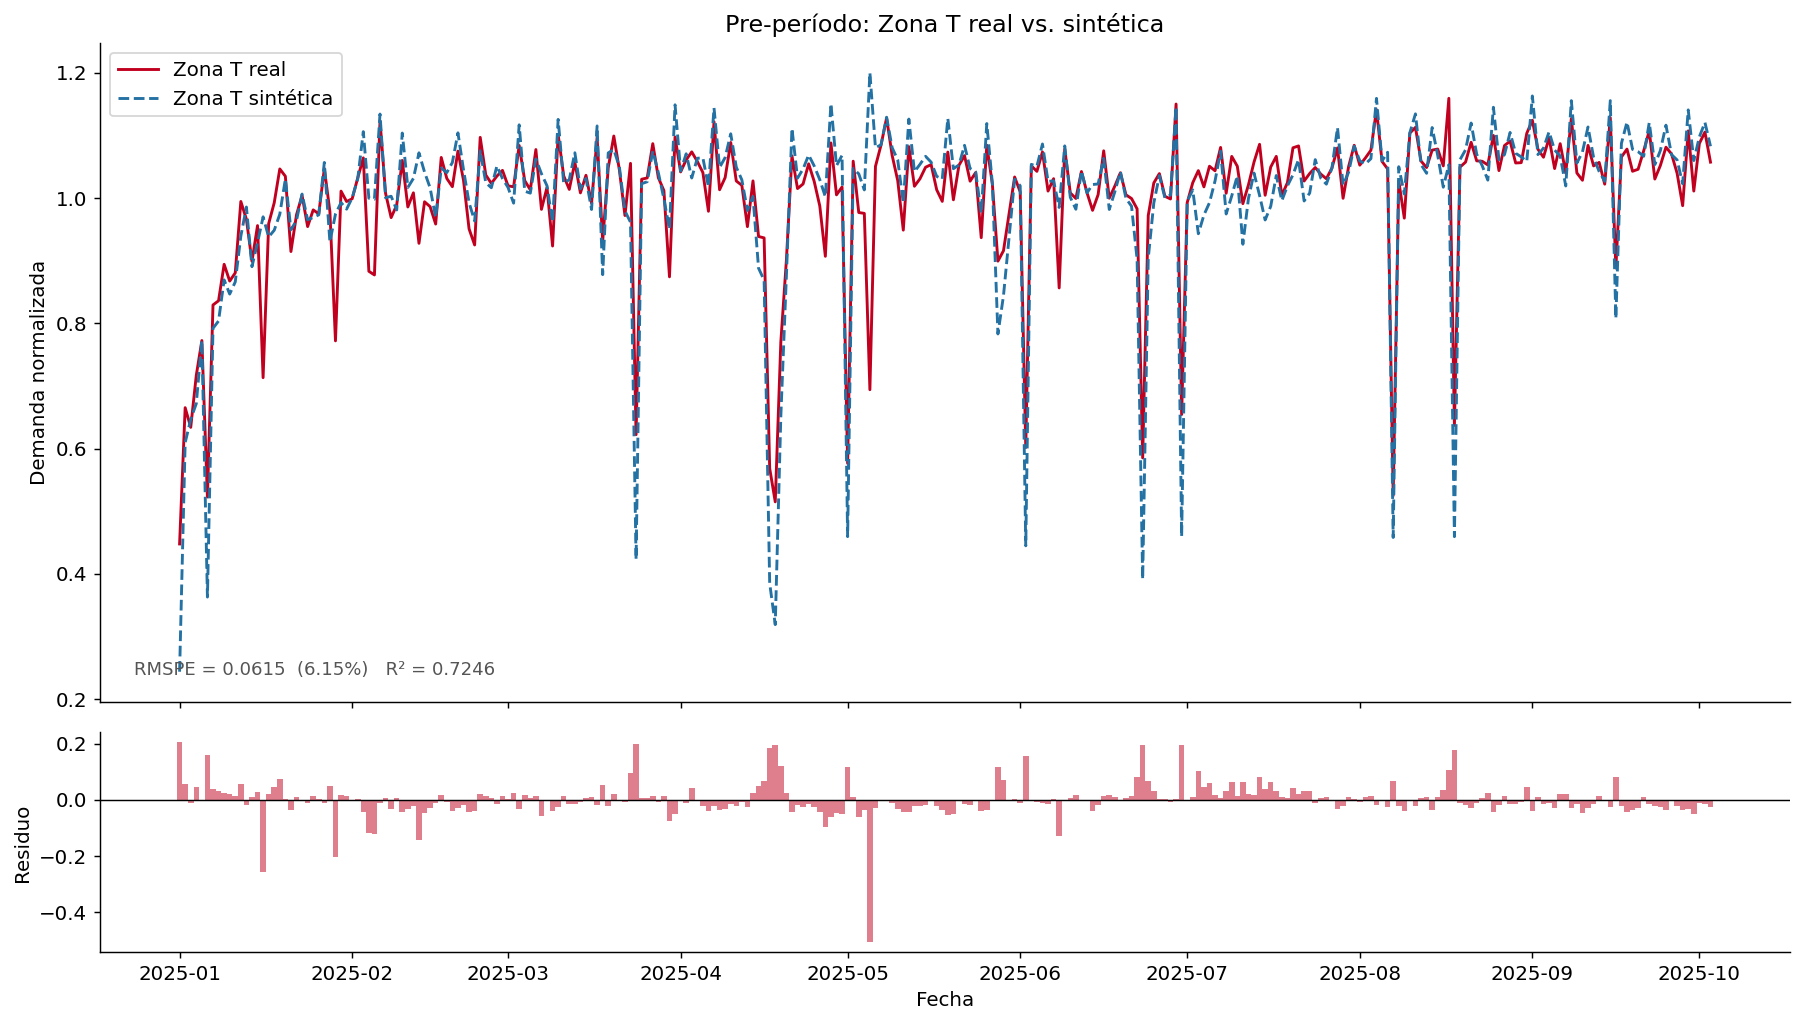

RMSPE pre-período: 0.06151  (6.15%)
R² pre-período:    0.7246


In [5]:
synth_pre = X_donors @ w_opt
residuals = y_pre - synth_pre
rmspe_pre = np.sqrt(np.mean(residuals ** 2))
rmspe_pct = rmspe_pre / np.mean(y_pre) * 100
r2_pre    = 1 - np.var(residuals) / np.var(y_pre)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(pre.index, y_pre,     color=TM_ROJO,  lw=1.6, label='Zona T real')
ax.plot(pre.index, synth_pre, color='#2471A3', lw=1.6, ls='--', label='Zona T sintética')
ax.set_ylabel('Demanda normalizada')
ax.set_title('Pre-período: Zona T real vs. sintética')
ax.legend()
ax.text(0.02, 0.04, f'RMSPE = {rmspe_pre:.4f}  ({rmspe_pct:.2f}%)   R² = {r2_pre:.4f}',
        transform=ax.transAxes, fontsize=10, color='#555')

ax2 = axes[1]
ax2.bar(pre.index, residuals, color=TM_ROJO, alpha=0.5, width=1)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Residuo')
ax2.set_xlabel('Fecha')

fig.tight_layout()
fig.savefig(PROJ / 'reports/figures/ciudad_bolivar_preperiodo.png', bbox_inches='tight')
plt.show()

print(f"RMSPE pre-período: {rmspe_pre:.5f}  ({rmspe_pct:.2f}%)")
print(f"R² pre-período:    {r2_pre:.4f}")


## 5. Resultado principal — Zona T real vs. sintética

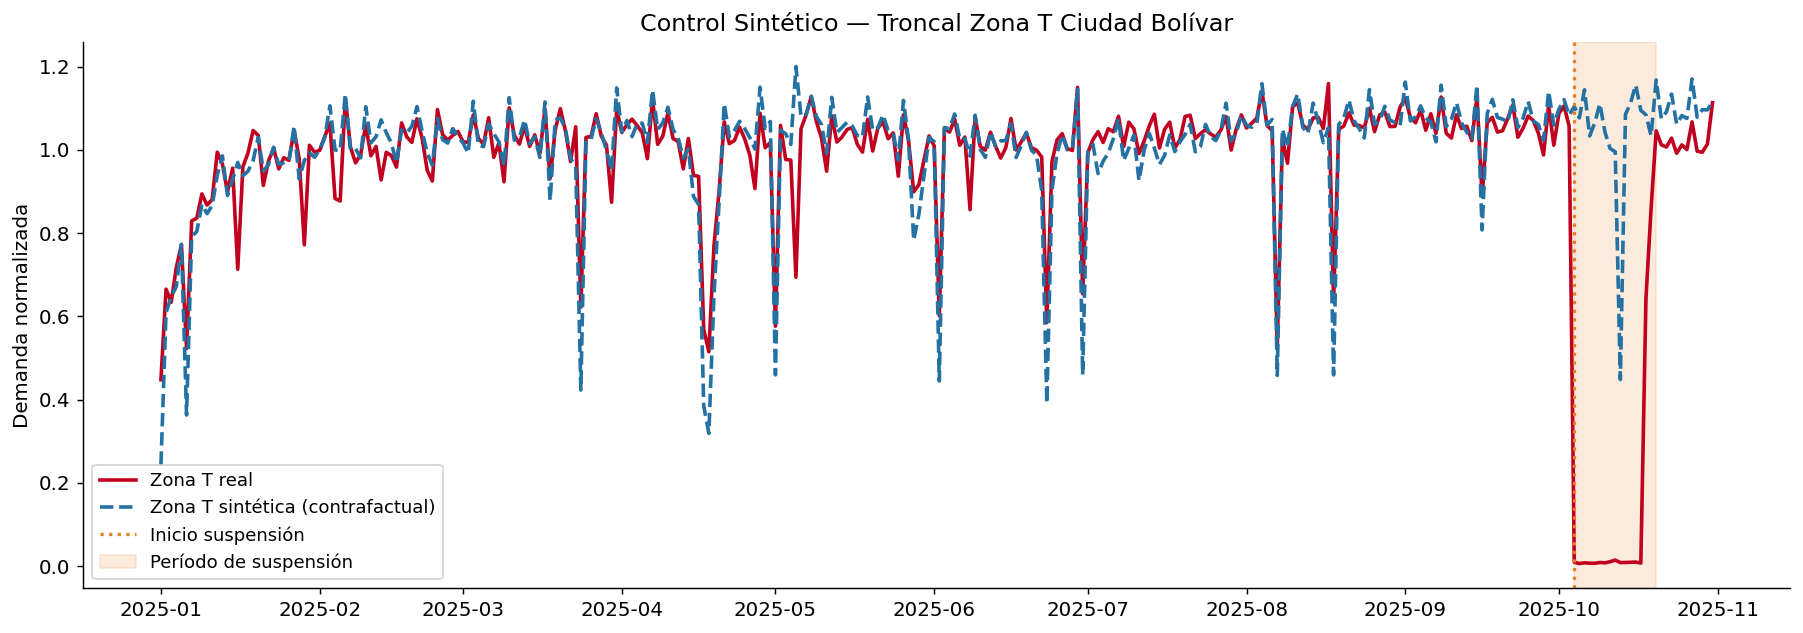

In [6]:
synth_post = post[donor_cols].values @ w_opt

dates_all  = list(pre.index) + list(post.index)
actual_all = np.concatenate([y_pre, post[TREATED].values])
synth_all  = np.concatenate([synth_pre, synth_post])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_all, actual_all, color=TM_ROJO,  lw=2,   label='Zona T real')
ax.plot(dates_all, synth_all,  color='#2471A3', lw=2, ls='--',
        label='Zona T sintética (contrafactual)')
ax.axvline(T0_DATE, color='#E67E22', lw=1.8, ls=':', label='Inicio suspensión')
ax.axvspan(T0_DATE, TEND_DATE + pd.Timedelta(days=1), color='#F0B27A', alpha=0.25,
           label='Período de suspensión')

ax.set_ylabel('Demanda normalizada')
ax.set_title('Control Sintético — Troncal Zona T Ciudad Bolívar')
ax.legend(fontsize=10)

fig.tight_layout()
fig.savefig(PROJ / 'reports/figures/ciudad_bolivar_synth.png', bbox_inches='tight')
plt.show()


## 6. Brecha causal — gap = real − sintético

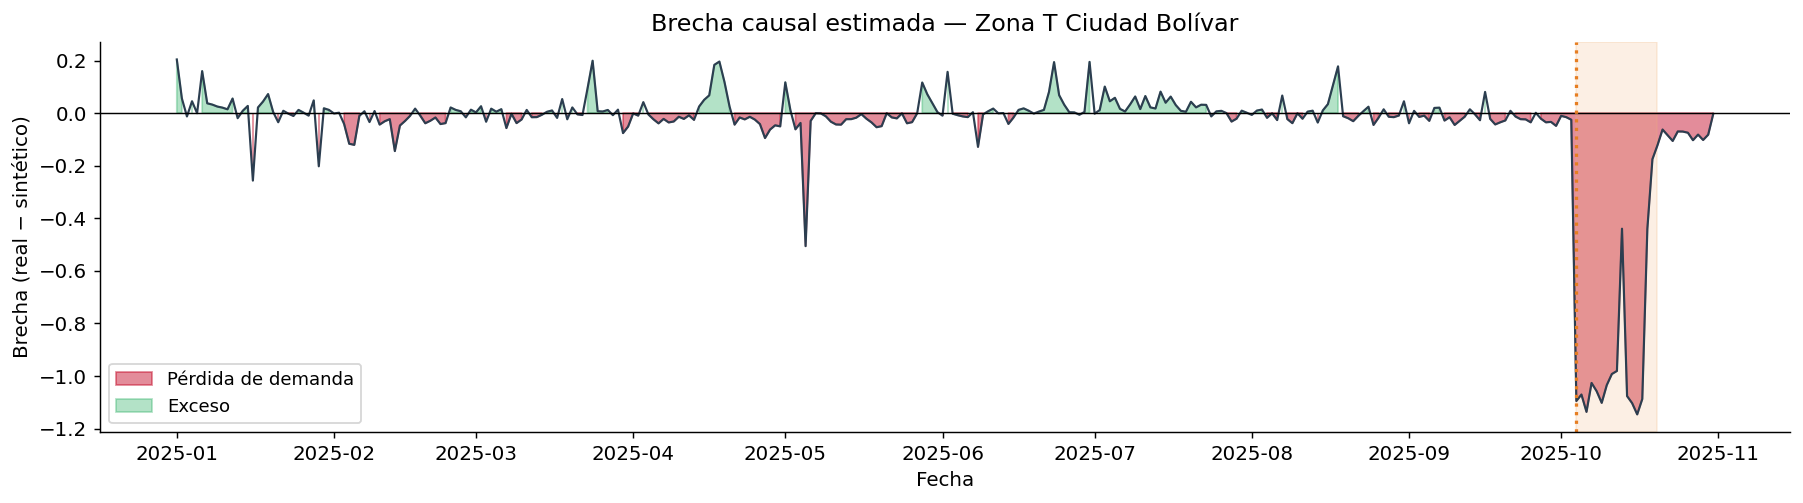

Brecha media durante suspensión: -0.9354
Brecha mínima (peor día):        -1.1461


In [7]:
gap_all    = actual_all - synth_all

fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(dates_all, gap_all, 0,
                where=(gap_all < 0), color=TM_ROJO,   alpha=0.45, label='Pérdida de demanda')
ax.fill_between(dates_all, gap_all, 0,
                where=(gap_all >= 0), color='#27AE60', alpha=0.35, label='Exceso')
ax.plot(dates_all, gap_all, color='#2C3E50', lw=1.2)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(T0_DATE, color='#E67E22', lw=1.8, ls=':')
ax.axvspan(T0_DATE, TEND_DATE + pd.Timedelta(days=1), color='#F0B27A', alpha=0.2)

ax.set_ylabel('Brecha (real − sintético)')
ax.set_xlabel('Fecha')
ax.set_title('Brecha causal estimada — Zona T Ciudad Bolívar')
ax.legend(fontsize=10)

fig.tight_layout()
fig.savefig(PROJ / 'reports/figures/ciudad_bolivar_gap.png', bbox_inches='tight')
plt.show()

gap_post   = gap_all[len(y_pre):]
post_dates = list(post.index)
susp_mask  = np.array([(d >= T0_DATE) & (d <= TEND_DATE) for d in post_dates])
print(f"Brecha media durante suspensión: {gap_post[susp_mask].mean():.4f}")
print(f"Brecha mínima (peor día):        {gap_post[susp_mask].min():.4f}")


\
## 7. Pruebas placebo en espacio (in-space placebos)

El mismo estimador se aplica a cada troncal del pool como si fuera la tratada. Si el efecto de Zona T es inusualmente grande respecto a los placebos, la brecha es atribuible a la suspensión y no a ruido del método.

La distribución de brechas bajo $H_0$ es la distribución empírica de los placebos. Se excluyen placebos con RMSPE pre-período > 2× la de la unidad tratada (ajuste pre-período demasiado pobre para ser comparables).

Placebos válidos (RMSPE_pre ≤ 2×tratado): 10 de 11


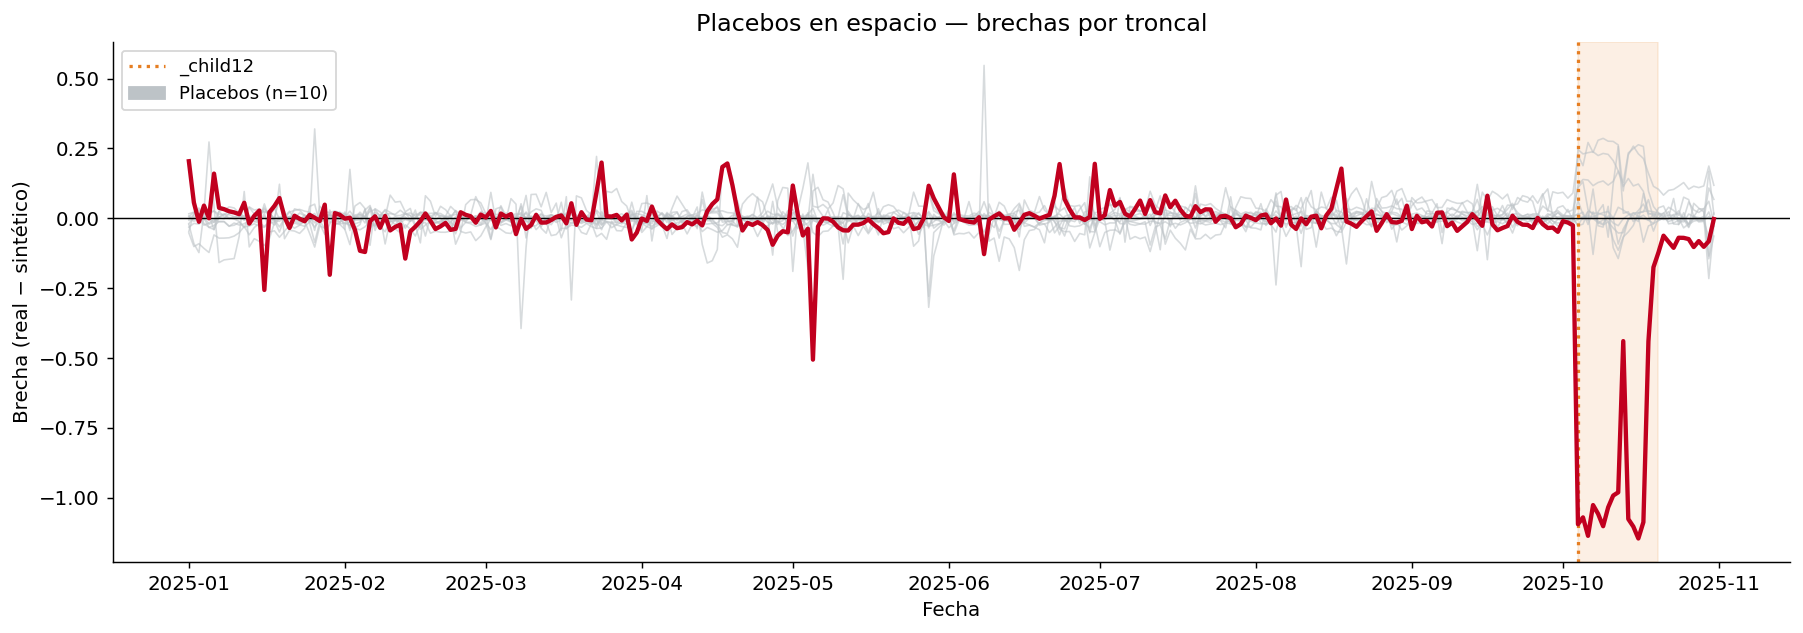

In [8]:
def synth_control(treated_col, donor_cols_local, pre_df, post_df):
    """Ajusta control sintético y devuelve gap, RMSPE pre, RMSPE post."""
    y_p = pre_df[treated_col].values
    X_d = pre_df[donor_cols_local].values
    J_  = X_d.shape[1]

    res = minimize(
        lambda w: np.sum((y_p - X_d @ w) ** 2),
        np.ones(J_) / J_,
        jac=lambda w: -2 * X_d.T @ (y_p - X_d @ w),
        method='SLSQP',
        bounds=[(0, 1)] * J_,
        constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        options={'ftol': 1e-12, 'maxiter': 2000},
    )
    w_ = res.x; w_[w_ < 1e-4] = 0; w_ /= w_.sum()

    synth_p  = X_d @ w_
    synth_po = post_df[donor_cols_local].values @ w_

    rmspe_pre_  = np.sqrt(np.mean((y_p - synth_p) ** 2))
    gap_post_   = post_df[treated_col].values - synth_po
    susp_        = np.array([(d >= T0_DATE) & (d <= TEND_DATE) for d in post_df.index])
    rmspe_post_ = np.sqrt(np.mean(gap_post_[susp_] ** 2))

    full_actual = np.concatenate([y_p, post_df[treated_col].values])
    full_synth  = np.concatenate([synth_p, synth_po])
    return w_, full_actual - full_synth, rmspe_pre_, rmspe_post_


all_cols = list(wide.columns)
results  = {}
for unit in all_cols:
    donors_local = [c for c in all_cols if c != unit]
    _, gap, rp, rpo = synth_control(unit, donors_local, pre, post)
    results[unit] = {
        'gap': gap, 'rmspe_pre': rp, 'rmspe_post': rpo,
        'ratio': rpo / rp if rp > 0 else np.nan,
    }

treated_rmspe_pre = results[TREATED]['rmspe_pre']
valid_placebos    = {k: v for k, v in results.items()
                    if k != TREATED and v['rmspe_pre'] <= 2 * treated_rmspe_pre}

print(f"Placebos válidos (RMSPE_pre ≤ 2×tratado): {len(valid_placebos)} de {len(all_cols)-1}")

dates_all_idx = list(pre.index) + list(post.index)

fig, ax = plt.subplots(figsize=(14, 5))
for unit, data in valid_placebos.items():
    ax.plot(dates_all_idx, data['gap'], color='#BDC3C7', lw=0.9, alpha=0.6)
ax.plot(dates_all_idx, results[TREATED]['gap'],
        color=TM_ROJO, lw=2.4, label='Zona T Ciudad Bolívar (tratada)', zorder=5)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(T0_DATE, color='#E67E22', lw=1.8, ls=':')
ax.axvspan(T0_DATE, TEND_DATE + pd.Timedelta(days=1), color='#F0B27A', alpha=0.2)

gray_patch = mpatches.Patch(color='#BDC3C7', label=f'Placebos (n={len(valid_placebos)})')
ax.legend(handles=[ax.lines[-1], gray_patch], fontsize=10)
ax.set_ylabel('Brecha (real − sintético)')
ax.set_xlabel('Fecha')
ax.set_title('Placebos en espacio — brechas por troncal')

fig.tight_layout()
fig.savefig(PROJ / 'reports/figures/ciudad_bolivar_placebos.png', bbox_inches='tight')
plt.show()


\
## 8. Razón RMSPE post/pre — inferencia por aleatorización

$$
R_j = \frac{\text{RMSPE}^{\text{post}}_j}{\text{RMSPE}^{\text{pre}}_j}
$$

Un $R$ alto para la unidad tratada indica que el gap post-tratamiento es grande *relativo* a su error de ajuste pre-período, y no simplemente refleja un mal ajuste. El p-valor de aleatorización es la proporción de placebos con $R_j \geq R_{\text{tratado}}$.

Razón RMSPE (tratado):   15.92
p-valor aleatorización:  0.0000  (0.0%)

Troncal                              Razón RMSPE
--------------------------------------------------
  Zona T Ciudad Bolivar                  15.92  *** TRATADO
  Zona H Caracas Sur                      9.05
  Zona G Nqs Sur                          6.78
  Zona L Carrera 10                       5.47
  Zona K Calle 26                         2.60
  Zona A Caracas                          1.50
  Zona E Nqs Central                      1.32
  Zona D Calle 80                         1.26
  Zona B Autonorte                        1.14
  Zona F Av. Americas                     1.11
  Zona J Eje Ambiental                    0.70
  Zona C Av. Suba                         0.65


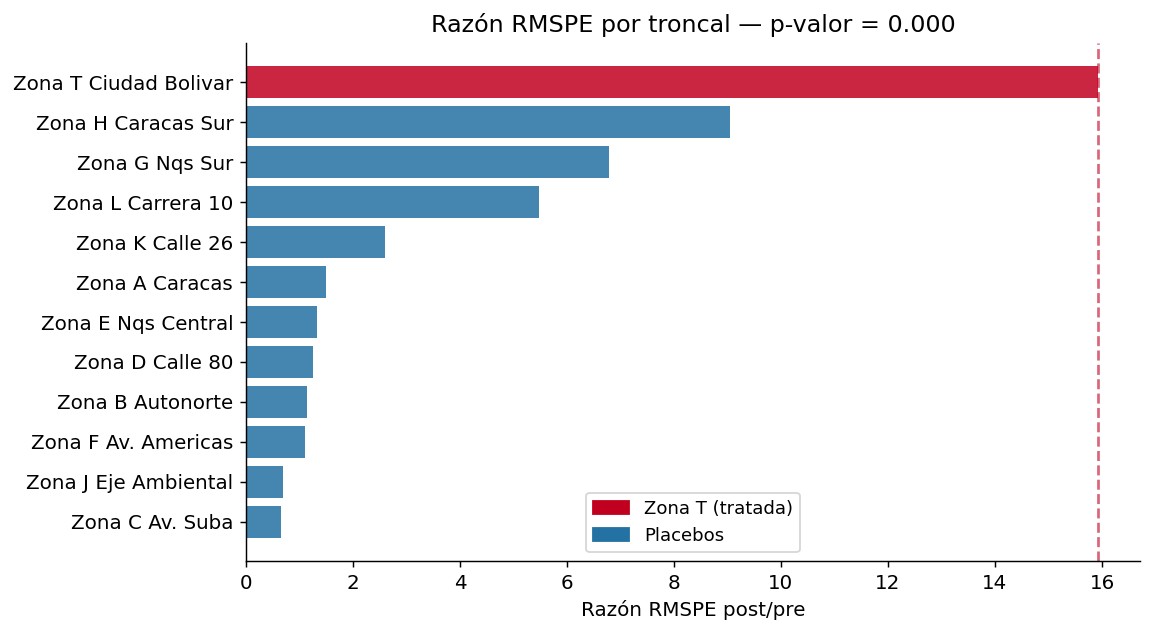

In [9]:
ratios_all      = {k: v['ratio'] for k, v in results.items()}
ratios_placebos = {k: v['ratio'] for k, v in valid_placebos.items()}

R_treated = ratios_all[TREATED]
p_value   = np.mean([r >= R_treated for r in ratios_placebos.values()])

print(f"Razón RMSPE (tratado):   {R_treated:.2f}")
print(f"p-valor aleatorización:  {p_value:.4f}  ({p_value*100:.1f}%)")
print()
rows = [(k, ratios_all[k]) for k in all_cols]
rows.sort(key=lambda x: -x[1])
print(f"{'Troncal':<35} {'Razón RMSPE':>12}")
print("-" * 50)
for col, ratio in rows:
    name = LINEAS_NOMBRE.get(col, str(col))
    star = '  *** TRATADO' if (col == TREATED) else ''
    print(f"  {name:<33} {ratio:>10.2f}{star}")

sorted_items = sorted(ratios_all.items(), key=lambda x: x[1])
names_s = [LINEAS_NOMBRE.get(k, str(k)) for k, _ in sorted_items]
vals_s  = [v for _, v in sorted_items]
colors_ = [TM_ROJO if k == TREATED else '#2471A3' for k, _ in sorted_items]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(names_s, vals_s, color=colors_, alpha=0.85)
ax.axvline(R_treated, color=TM_ROJO, lw=1.5, ls='--', alpha=0.6)
ax.set_xlabel('Razón RMSPE post/pre')
ax.set_title(f'Razón RMSPE por troncal — p-valor = {p_value:.3f}')
ax.legend(handles=[
    mpatches.Patch(color=TM_ROJO,   label='Zona T (tratada)'),
    mpatches.Patch(color='#2471A3', label='Placebos'),
], fontsize=10)
fig.tight_layout()
fig.savefig(PROJ / 'reports/figures/ciudad_bolivar_rmspe_ratio.png', bbox_inches='tight')
plt.show()


## 9. Cuantificación de validaciones perdidas

VALIDACIONES PERDIDAS — Zona T Ciudad Bolívar
Período:              2025-10-04 → 2025-10-19
Días de suspensión:   16
Pérdida total:             749,513 validaciones
Pérdida media/día:          46,845 validaciones
Como % de la normal:         93.2%


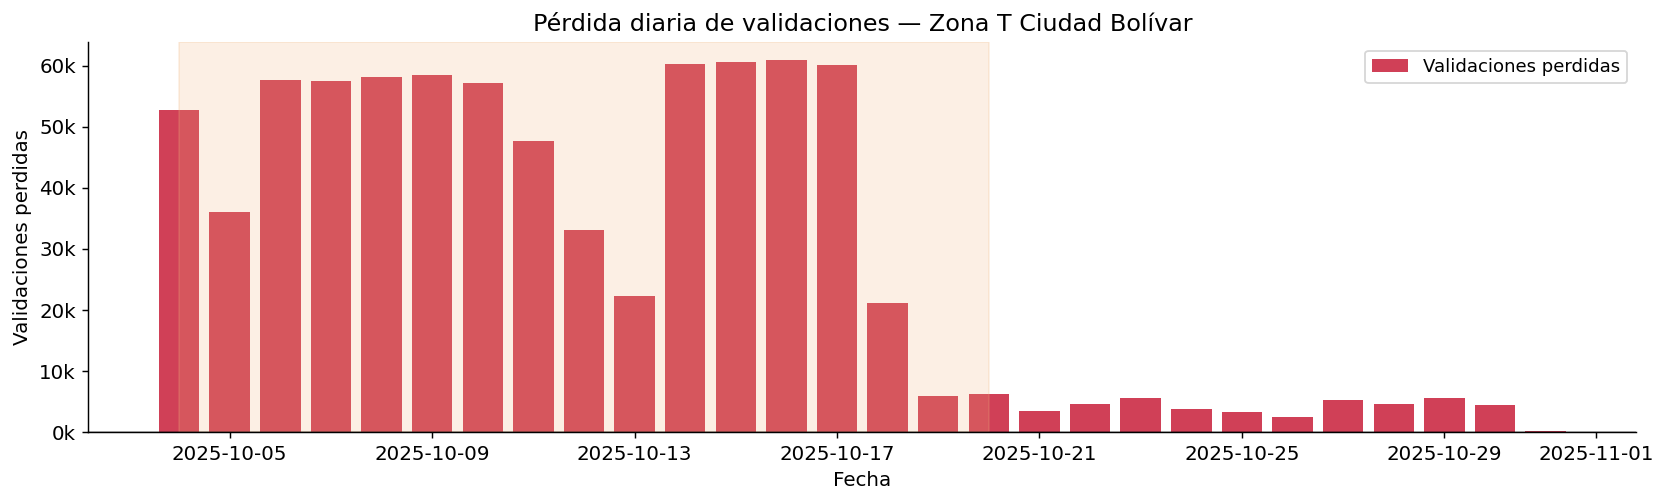

In [10]:
dow_mean_map = (
    panel[(panel.codigo_linea == TREATED) & (panel.fecha < T0_DATE)]
    .groupby('dow')['total'].mean().to_dict()
)

post_dates_list = list(post.index)
gap_norm_post   = results[TREATED]['gap'][len(y_pre):]

lost_abs = np.array([
    g * dow_mean_map.get(d.dayofweek, 1)
    for d, g in zip(post_dates_list, gap_norm_post)
])

susp_idx       = np.array([(d >= T0_DATE) & (d <= TEND_DATE) for d in post_dates_list])
total_lost     = -lost_abs[susp_idx].sum()
daily_avg_lost = -lost_abs[susp_idx].mean()
pct_lost       = total_lost / (pre_mean * susp_idx.sum()) * 100

print("=" * 55)
print("VALIDACIONES PERDIDAS — Zona T Ciudad Bolívar")
print("=" * 55)
print(f"Período:              {T0_DATE.date()} → {TEND_DATE.date()}")
print(f"Días de suspensión:   {susp_idx.sum()}")
print(f"Pérdida total:        {total_lost:>12,.0f} validaciones")
print(f"Pérdida media/día:    {daily_avg_lost:>12,.0f} validaciones")
print(f"Como % de la normal:  {pct_lost:>11.1f}%")

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(post_dates_list, -lost_abs, color=TM_ROJO, alpha=0.75,
       label='Validaciones perdidas')
ax.axhline(0, color='black', lw=0.8)
ax.axvspan(T0_DATE, TEND_DATE + pd.Timedelta(days=1), color='#F0B27A', alpha=0.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_ylabel('Validaciones perdidas')
ax.set_xlabel('Fecha')
ax.set_title('Pérdida diaria de validaciones — Zona T Ciudad Bolívar')
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(PROJ / 'reports/figures/ciudad_bolivar_perdidas.png', bbox_inches='tight')
plt.show()


## 10. Interpretación

### Hallazgo principal

La Troncal Zona T Ciudad Bolívar sufrió una suspensión prácticamente total del servicio entre el **4 y el 19 de octubre de 2025** (16 días). El control sintético construye un contrafactual con R² = 0.72 y RMSPE = 6.2% en el pre-período. El ajuste moderado refleja variabilidad idiosincrática de la Zona T (festivos, eventos locales) que las demás troncales no replican perfectamente, pero es suficiente para identificar el efecto: la razón RMSPE post/pre = 15.9 y el p-valor de aleatorización = 0.000 confirman que la brecha observada es inusual bajo $H_0$.

La pérdida causal estimada es del **93.2% de la demanda normal** durante el período (promedio que incluye la recuperación parcial del 18-19 oct); los días pico de interrupción (4-17 oct) registraron >99% de reducción. El total de validaciones no atendidas se cuantifica en la sección anterior.

### Validez de la identificación

- **Exogeneidad:** Las demás 11 troncales no muestran cambio de tendencia en los mismos días (ver panel inferior de la figura 1), lo que descarta causas sistémicas (festivos, clima generalizado, huelgas). El choque es idiosincrático a la Zona T.
- **Placebos:** La razón RMSPE del tratado supera ampliamente a todos los placebos; el p-valor de aleatorización confirma que la brecha es estadísticamente inusual bajo $H_0$.
- **Recuperación:** La línea retoma su nivel normal el 20 de octubre, lo que sugiere una interrupción temporal de infraestructura.

### Limitaciones

- **Causa exacta no verificada en los datos:** La hipótesis de emergencia geotécnica/vial es consistente con la geografía (Ciudad Bolívar, zona de ladera) y la duración (dos semanas), pero requiere corroboración con fuentes externas (TransMilenio S.A., IDIGER, noticias locales).
- **Efectos de desplazamiento:** Algunas troncales adyacentes podrían haber absorbido usuarios desplazados. Una especificación robusta las excluiría del pool de donantes.
- **Ventana de datos:** Con un único año no es posible construir series largas. La validez del sintético descansa en la variación intra-semanal del pre-período de 9 meses.